# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [2]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

In [3]:
df.isnull().sum()

title             0
Marca             0
Preco_Normal      0
Preco_Desconto    0
Preco_Anterior    0
Desconto          0
Categoria         0
dtype: int64

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [4]:
# Preço normal média por categoria
preco_por_categoria = (
    df.groupby('Categoria')['Preco_Normal']
    .mean() # calcula a média
    .round(2) # arredonda para duas casas decimais
    .reset_index() # arruma os indices para numeros
    .rename(columns={'Preco_Normal': 'Preco_Normal_Media'}) # renomeia a coluna para ficar mais consistente
    .sort_values(by='Preco_Normal_Media', ascending=False) # arruma em ordem decrescente os valores
).reset_index(drop=True) # arruma a ordem dos indices

preco_por_categoria

,Categoria,Preco_Normal_Media
0,comidas-preparadas,3095.04
1,lacteos,2385.22
2,congelados,2108.04
3,belleza-y-cuidado-personal,1783.56
4,frutas,1724.47
5,verduras,1343.30
6,instantaneos-y-sopas,765.49


In [5]:
# Mediana dos preços normais por categoria
mediana_series = df.groupby('Categoria')['Preco_Normal'].median().round(2)

# une para a mesma variavel o preço das medianas das categorias
preco_por_categoria['Preco_Normal_Mediana'] = preco_por_categoria[
    'Categoria'
].map(mediana_series)

preco_por_categoria = preco_por_categoria.round(2)

preco_por_categoria

,Categoria,Preco_Normal_Media,Preco_Normal_Mediana
0,comidas-preparadas,3095.04,3290.0
1,lacteos,2385.22,989.0
2,congelados,2108.04,1519.0
3,belleza-y-cuidado-personal,1783.56,1569.0
4,frutas,1724.47,1195.0
5,verduras,1343.30,1180.0
6,instantaneos-y-sopas,765.49,439.0


Observa-se que a maioria das categorias apresenta média superior à mediana (`lacteos`, `congelados`, `belleza-y-cuidado-personal`, `frutas`, `verduras` e `instantaneos-y-sopas`), indicando a presença de *outliers* com valores elevados que distorcem a média para cima.

Em contrapartida, apenas a categoria `comidas-preparadas` apresenta média inferior à mediana. Isso sugere a presença de alguns itens com preços muito baixos, enquanto a maior parte dos produtos concentra-se em torno de 3.290.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [6]:
# Cálculo do desvio padrão dos preços por produto
desvio_padrao_series = df.groupby('Categoria')['Preco_Normal'].std().round(2)

# União na dataframe anterior do desvio padrão
preco_por_categoria['Desvio_Padrao'] = preco_por_categoria[
    'Categoria'
].map(desvio_padrao_series) 

preco_por_categoria.sort_values(by='Desvio_Padrao', ascending=False) # Mostra os valores em ordem decrescente para o desvio padrão

,Categoria,Preco_Normal_Media,Preco_Normal_Mediana,Desvio_Padrao
1,lacteos,2385.22,989.0,3925.82
3,belleza-y-cuidado-personal,1783.56,1569.0,2210.04
2,congelados,2108.04,1519.0,2111.54
0,comidas-preparadas,3095.04,3290.0,2019.91
4,frutas,1724.47,1195.0,1639.15
6,instantaneos-y-sopas,765.49,439.0,1170.23
5,verduras,1343.30,1180.0,1012.70


A categoria `lacteos` apresenta o maior desvio padrão entre todas as analisadas. Esse comportamento reflete a grande disparidade entre a sua média e a sua mediana, sendo a média aproximadamente 2,4 vezes superior à mediana.

A divergência entre essas medidas de tendência central, combinada à alta dispersão (desvio padrão elevado), evidencia uma forte assimetria à direita nos dados — com destaque para `lacteos` e `instantaneos-y-sopas`, indicando a presença de valores atípicos (outliers) que puxam a média para cima.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA']

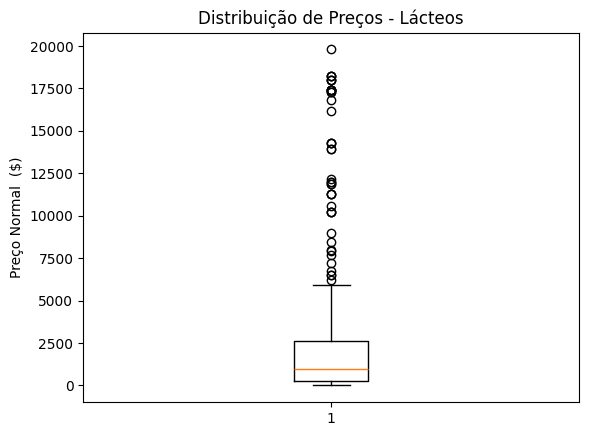

In [7]:
#Seu código aqui
precos_lacteos = df[df['Categoria'] == 'lacteos']['Preco_Normal']

plt.boxplot(precos_lacteos)

plt.title('Distribuição de Preços - Lácteos')
plt.ylabel('Preço Normal  ($)')
plt.show()

In [8]:
# Cálculo dos quartis e limites
Q1 = precos_lacteos.quantile(0.25)
Q3 = precos_lacteos.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Quantificação de outliers
quantidade_outliers = (precos_lacteos > limite_superior).sum()
percentual_outliers = (quantidade_outliers / len(precos_lacteos)) * 100

print(f"1º Quartil (Q1):      $ {Q1:,.2f}")
print(f"Mediana (Q2):         $ {precos_lacteos.median():,.2f}")
print(f"3º Quartil (Q3):      $ {Q3:,.2f}")
print(f"Limite Superior:      $ {limite_superior:,.2f}")
print(f"Outliers detectados:  {quantidade_outliers} ({percentual_outliers:.1f}% da base)")

1º Quartil (Q1):      $ 269.00
Mediana (Q2):         $ 989.00
3º Quartil (Q3):      $ 2,609.00
Limite Superior:      $ 6,119.00
Outliers detectados:  43 (9.6% da base)


Observa-se uma **assimetria positiva (à direita)** na distribuição dos preços, evidenciada pela posição da mediana (linha laranja em torno de 989), que se encontra deslocada para a base da distribuição. A amplitude entre o terceiro quartil ($Q_3$) e o limite superior é significativamente maior do que o intervalo entre o primeiro quartil ($Q_1$) e o limite inferior, reforçando a dispersão na cauda superior.

Além disso, nota-se uma expressiva quantidade de valores atípicos (*outliers*) acima do limite superior, calculado pelo método do Intervalo Interquartil ($IQR$):

$$Limite_{\text{superior}} = Q_3 + 1{,}5 \times IQR$$

*(onde $IQR = Q_3 - Q_1$)*


In [9]:
df_outliers_lacteos = df[
    (df["Preco_Normal"] > limite_superior) & (df["Categoria"] == "lacteos")
]

# colunas_interesse = ["title", "Preco_Normal"]

df_outliers_lacteos.sort_values(by="Preco_Normal", ascending=False).head()

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos


In [10]:
print("Observe que o cadastro está com um engradado de leite, sendo que o preço unitário do primeiro item seria:", 19788/12)

Observe que o cadastro está com um engradado de leite, sendo que o preço unitário do primeiro item seria: 1649.0


Identificou-se que a presença expressiva de *outliers* decorre, majoritariamente, de uma inconsistência no nível de agregação do cadastro (venda em fardo/engradado em vez de unidade avulsa). 

Para produtos comercializados exclusivamente em lotes, a melhor abordagem analítica consiste em criar uma variável de **quantidade por embalagem** (*pack size*) e derivar o **preço unitário**. Essa padronização garante a comparabilidade entre os itens e mitiga distorções na distribuição de preços da categoria.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

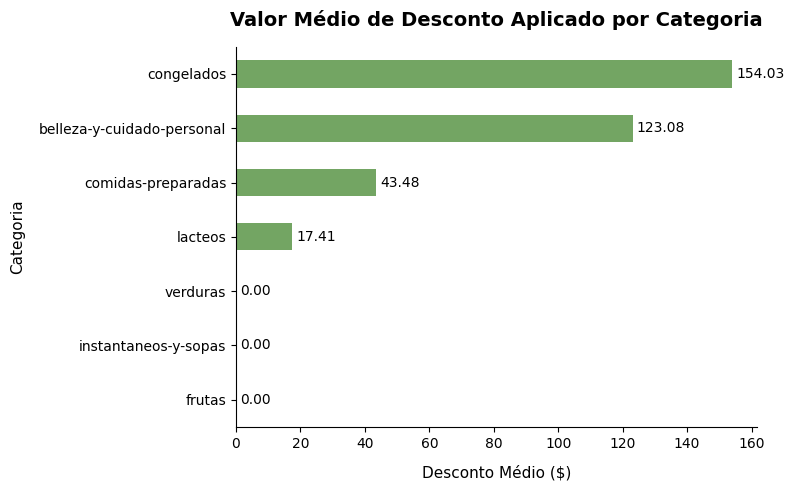

In [13]:
# Agregação e cálculo da média de descontos
descontos_por_categoria = (
    df.groupby("Categoria")["Desconto"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Desconto": "Desconto_Media"})
    .sort_values(by="Desconto_Media", ascending=True)
    .reset_index(drop=True)
)

# Construção do gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))

# plot do gráfico
descontos_por_categoria.plot(
    x="Categoria",
    y="Desconto_Media",  # Corrigido: usando o nome atualizado da coluna
    kind="barh", # barras horizontais
    color="#377E1FB2",
    legend=False,  # Remove a legenda desnecessária com apenas 1 métrica
    ax=ax,
)

# Customização e formatação visual
plt.title(
    "Valor Médio de Desconto Aplicado por Categoria",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Desconto Médio ($)", fontsize=11, labelpad=10)
plt.ylabel("Categoria", fontsize=11, labelpad=10)

# Rótulos de dados no topo de cada barra
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)

# Remove bordas desnecessárias (melhoria de DataViz)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

In [14]:
# Agregação por Categoria e Marca
mapa_produtos = (
    df.groupby(["Categoria", "Marca"])
    .agg(
        Desconto_Medio=("Desconto", "mean"),
        Quantidade_Produtos=("title", "count"),
    )
    .round(2)
    .reset_index()
)

# Construção do Treemap
fig = px.treemap(
    mapa_produtos,
    path=["Categoria", "Marca"],
    values="Quantidade_Produtos",
    color="Desconto_Medio",
    color_continuous_scale="RdBu",  # Escala sequencial para valores contínuos positivos
    custom_data=["Desconto_Medio", "Quantidade_Produtos"], # Para criar mostrar esses metadados conforme o mouse passa em cima dos itens
    labels={"Desconto_Medio": "Desconto Médio ($)"}, # Renomeação para a visualização
    title="Distribuição do Portfólio e Intensidade de Descontos por Categoria e Marca",
    height=800,
)

# Customização do Tooltip (Hover)
fig.update_traces(
    hovertemplate=(
        "<b>%{label}</b><br><br>" # Titulo/marca com quebra de linhas
        + "Desconto Médio: $ %{customdata[0]:,.2f}<br>" # Hover de marca
        + "Volume de Produtos: %{customdata[1]:,}<br>" # Hover de quantidade de produtos
        + "<extra></extra>"  # Oculta a caixa secundária padrão do Plotly
    )
)

# Ajuste fino de layout
fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    title_font_size=16,
)

fig.show()